# Laboratorio 5
Ignacio Mendez 22613 y Diego Soto 22737

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Task 1

### Validation

2846
Matches buenos encontrados 449


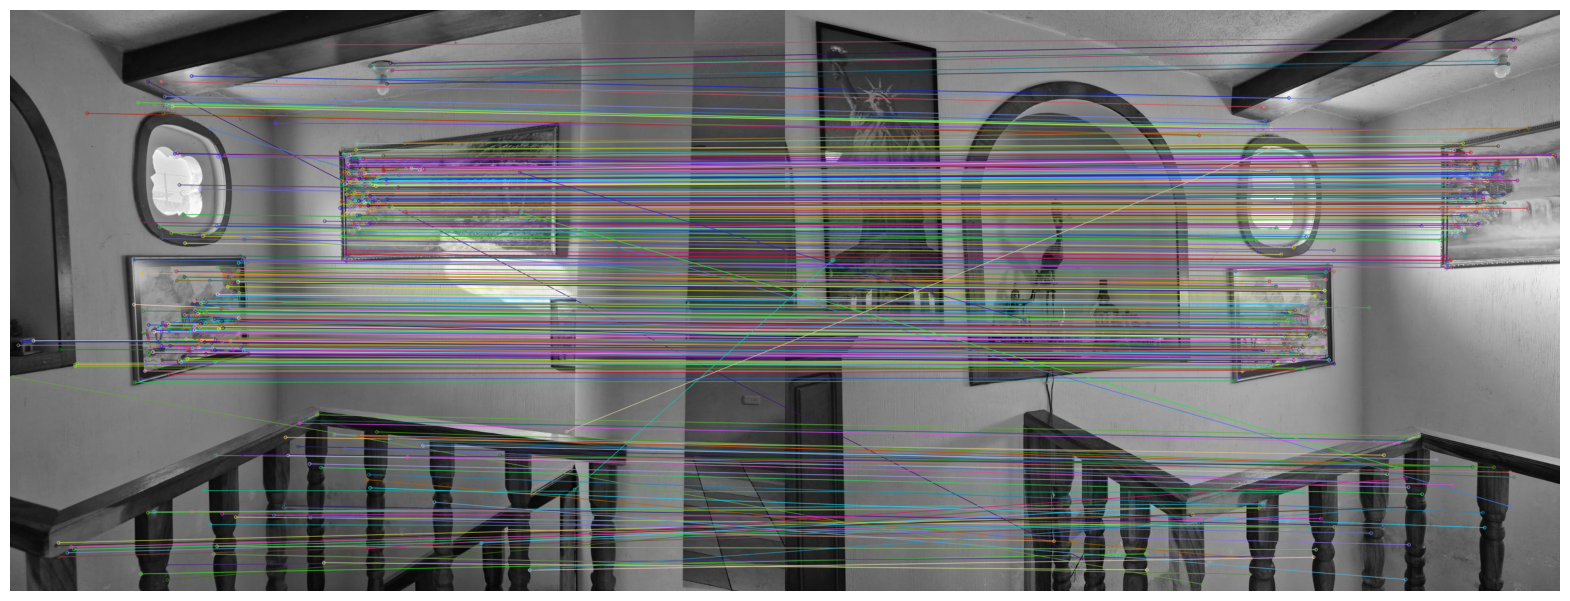

In [4]:
# cargar las imágenes
img_left = cv2.imread("val1i.jpeg")
img_right = cv2.imread("val1d.jpeg")

# convertir en grises
gray_left = cv2.cvtColor(img_left, cv2.COLOR_BGR2GRAY)
gray_right = cv2.cvtColor(img_right, cv2.COLOR_BGR2GRAY)

# SIFT para detectar keypoints
sift = cv2.SIFT_create()
kp_left, des_left = sift.detectAndCompute(gray_left, None) #Train (destino)
kp_right, des_right = sift.detectAndCompute(gray_right, None) #Query (origen)

# Matching Flann
FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm = FLANN_INDEX_KDTREE, trees = 5)
search_params = dict(checks = 50)
flann = cv2.FlannBasedMatcher(index_params, search_params)

# derecha es query
# izquierda es nuestro train
matches = flann.knnMatch(des_right, des_left, k = 2)
print(len(matches)) # son como 10 000 matches 

# lowe ratio test
good_matches = []
for m, n in matches: 
    if m.distance < 0.7 * n.distance:
        good_matches.append(m)

print(f"Matches buenos encontrados {len(good_matches)}")

# visualización
img_matches = cv2.drawMatches(gray_right, kp_right, gray_left, kp_left, good_matches, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
plt.figure(figsize=(20, 10))
plt.imshow(img_matches)
plt.axis('off')
plt.show()  

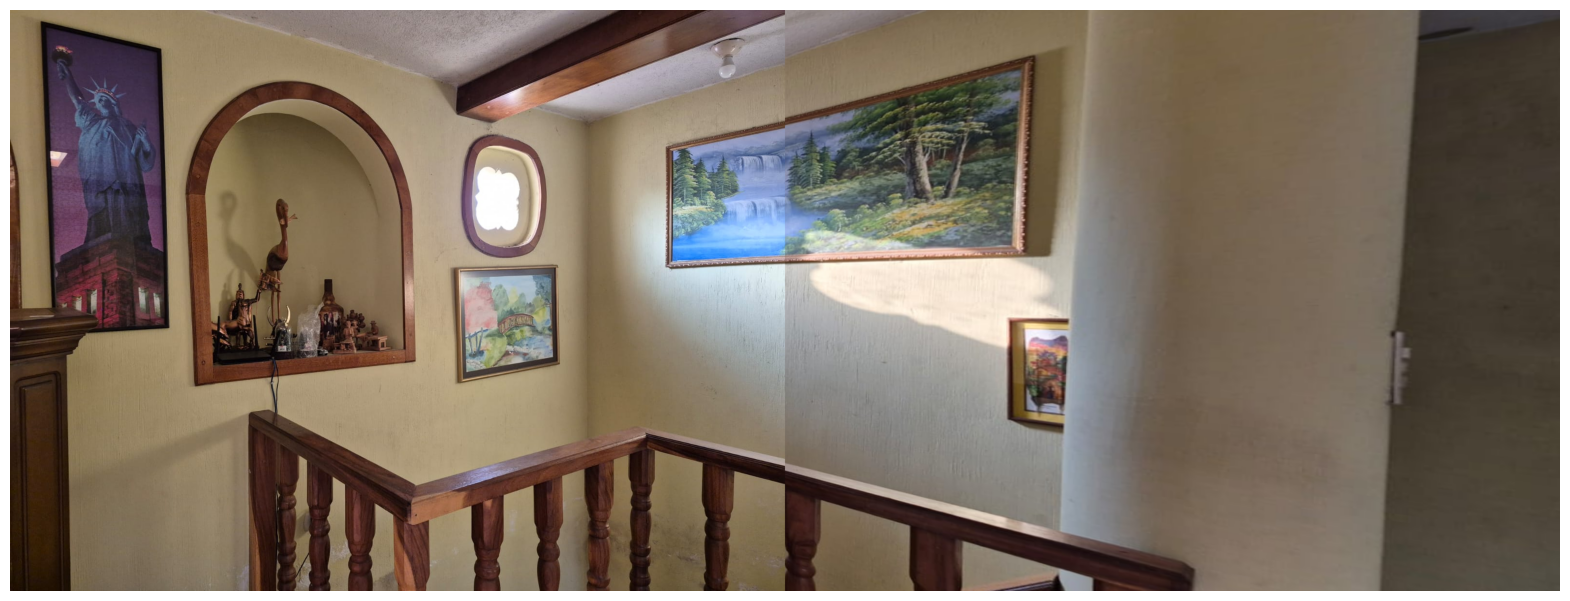

In [5]:
# homografía 

# extraer coordenadas de lso puntos 
src_pts = np.float32([kp_right[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
dst_pts = np.float32([kp_left[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

# ransac
M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

# wrap * deformación
# calcular nuestro canvas / lienzo
h_left, w_left = img_left.shape[:2]
h_right, w_right = img_right.shape[:2]

# ancho = i1.w + i2.w
canvas_w = w_left + w_right
canvas_h = max(h_left, h_right)

# deformamos la imagen de la derecha. Como la base es la izquiera, la derecha se moverá hacia coorddenadas positivas
panorama = cv2.warpPerspective(img_right, M, (canvas_w, canvas_h))
panorama[0:h_left, 0:w_left] = img_left

dst_rgb = cv2.cvtColor(panorama, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(20, 10))
plt.imshow(dst_rgb)
plt.axis('off')
plt.show()

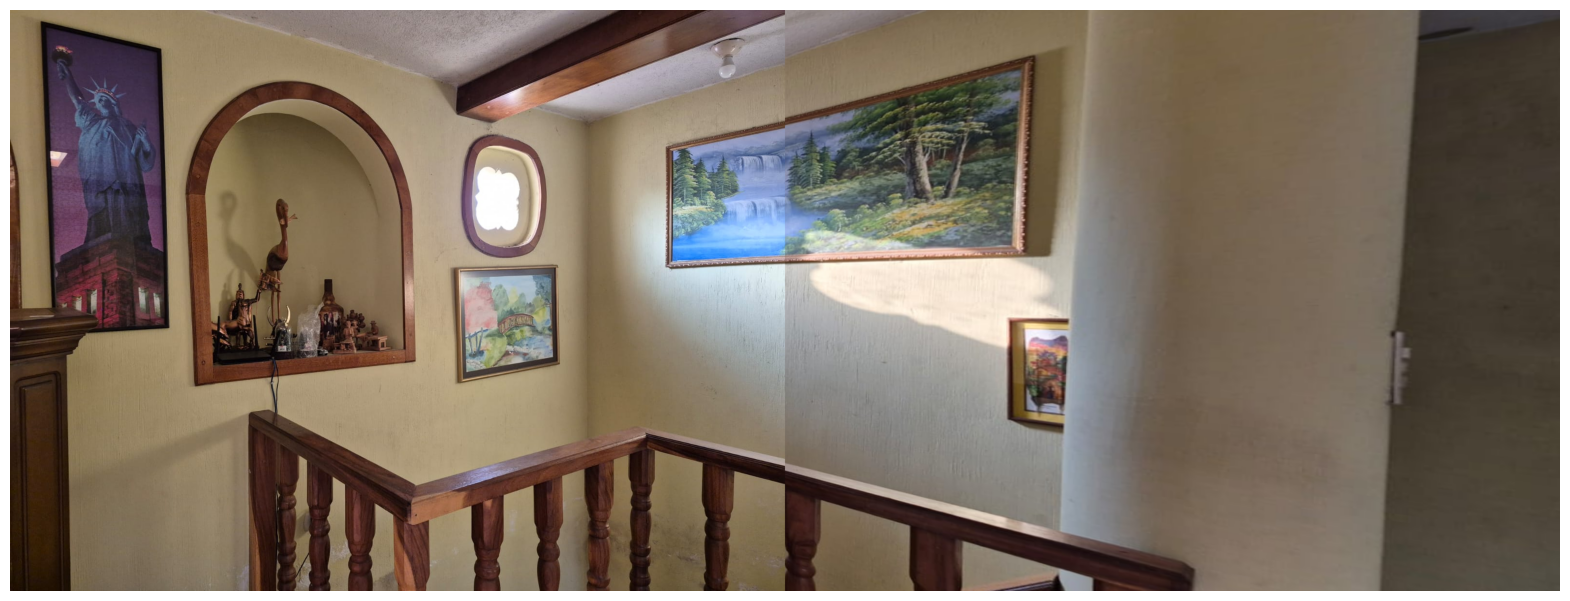

In [6]:
panorama_gray = cv2.cvtColor(panorama, cv2.COLOR_BGR2GRAY)
_, mask = cv2.threshold(panorama_gray, 1, 255, cv2.THRESH_BINARY)
mask_inv = cv2.bitwise_not(mask)
left_on_canvas = np.zeros_like(panorama)
left_on_canvas[0:h_left, 0:w_left] = img_left

img_left_part = cv2.bitwise_and(left_on_canvas, left_on_canvas, mask=mask_inv)
img_panorama_part = cv2.bitwise_and(panorama, panorama, mask=mask)
final_panorama = cv2.add(img_left_part, img_panorama_part)

dst_rgb = cv2.cvtColor(final_panorama, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(20, 10))
plt.imshow(dst_rgb)
plt.axis('off') 
plt.show()

### Descubrimiento

5185
Matches buenos encontrados 332


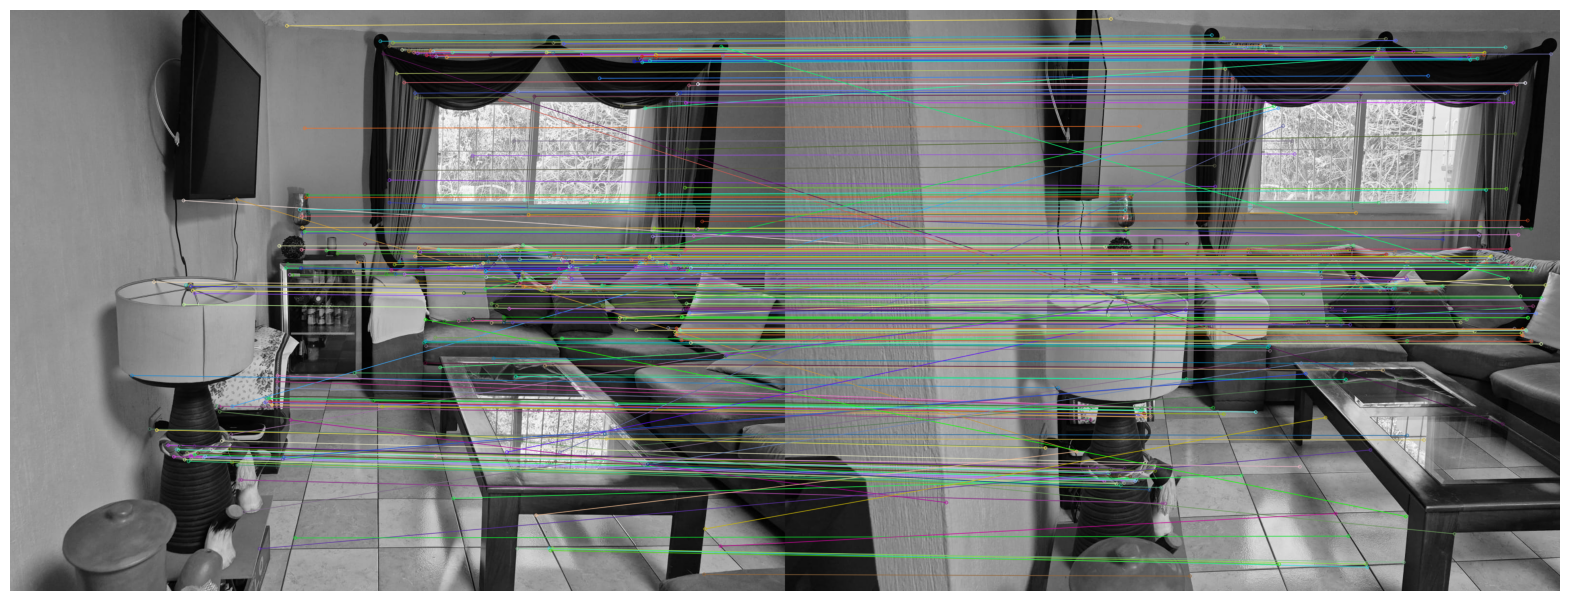

In [13]:
# cargar las imágenes
img_left = cv2.imread("des2i.jpeg")
img_right = cv2.imread("des2d.jpeg")

# convertir en grises
gray_left = cv2.cvtColor(img_left, cv2.COLOR_BGR2GRAY)
gray_right = cv2.cvtColor(img_right, cv2.COLOR_BGR2GRAY)

# SIFT para detectar keypoints
sift = cv2.SIFT_create()
kp_left, des_left = sift.detectAndCompute(gray_left, None) #Train (destino)
kp_right, des_right = sift.detectAndCompute(gray_right, None) #Query (origen)

# Matching Flann
FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm = FLANN_INDEX_KDTREE, trees = 5)
search_params = dict(checks = 50)
flann = cv2.FlannBasedMatcher(index_params, search_params)

# derecha es query
# izquierda es nuestro train
matches = flann.knnMatch(des_right, des_left, k = 2)
print(len(matches)) # son como 10 000 matches 

# lowe ratio test
good_matches = []
for m, n in matches: 
    if m.distance < 0.7 * n.distance:
        good_matches.append(m)

print(f"Matches buenos encontrados {len(good_matches)}")

# visualización
img_matches = cv2.drawMatches(gray_right, kp_right, gray_left, kp_left, good_matches, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
plt.figure(figsize=(20, 10))
plt.imshow(img_matches)
plt.axis('off')
plt.show()  

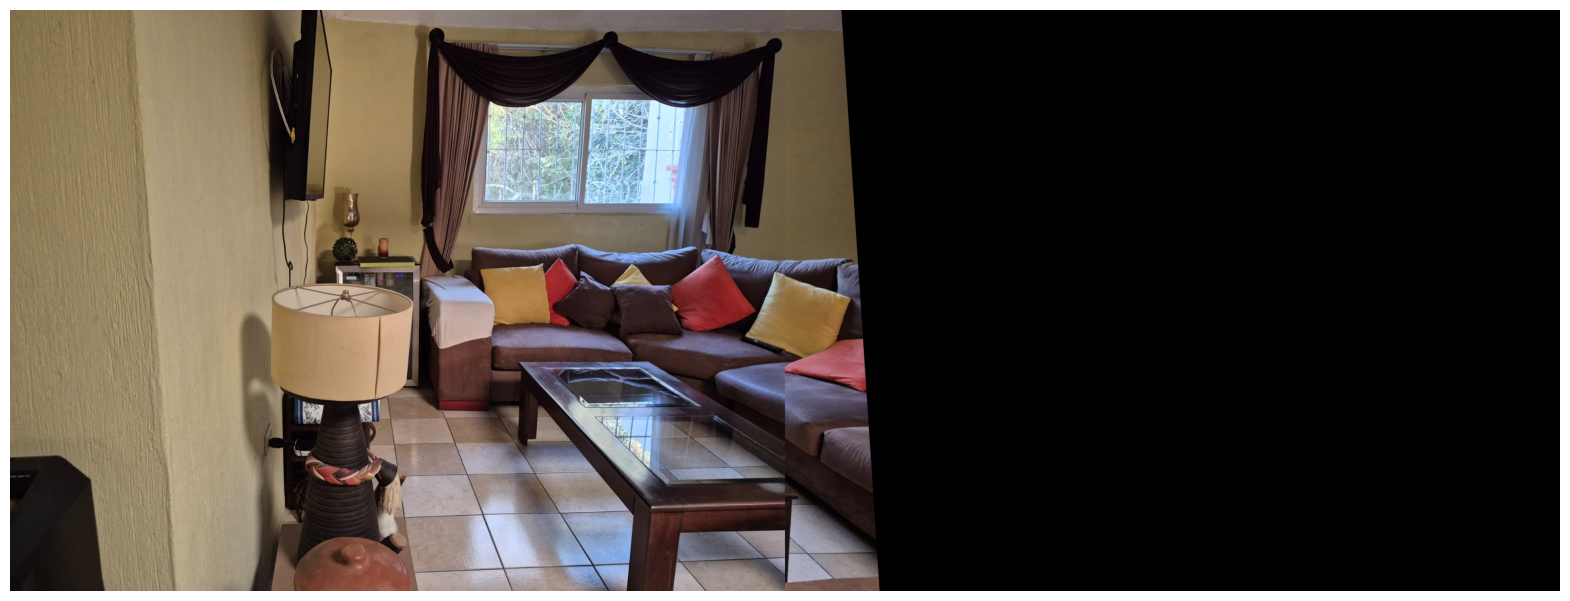

In [14]:
# homografía 

# extraer coordenadas de lso puntos 
src_pts = np.float32([kp_right[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
dst_pts = np.float32([kp_left[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

# ransac
M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

# wrap * deformación
# calcular nuestro canvas / lienzo
h_left, w_left = img_left.shape[:2]
h_right, w_right = img_right.shape[:2]

# ancho = i1.w + i2.w
canvas_w = w_left + w_right
canvas_h = max(h_left, h_right)

# deformamos la imagen de la derecha. Como la base es la izquiera, la derecha se moverá hacia coorddenadas positivas
panorama = cv2.warpPerspective(img_right, M, (canvas_w, canvas_h))
panorama[0:h_left, 0:w_left] = img_left

dst_rgb = cv2.cvtColor(panorama, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(20, 10))
plt.imshow(dst_rgb)
plt.axis('off')
plt.show()

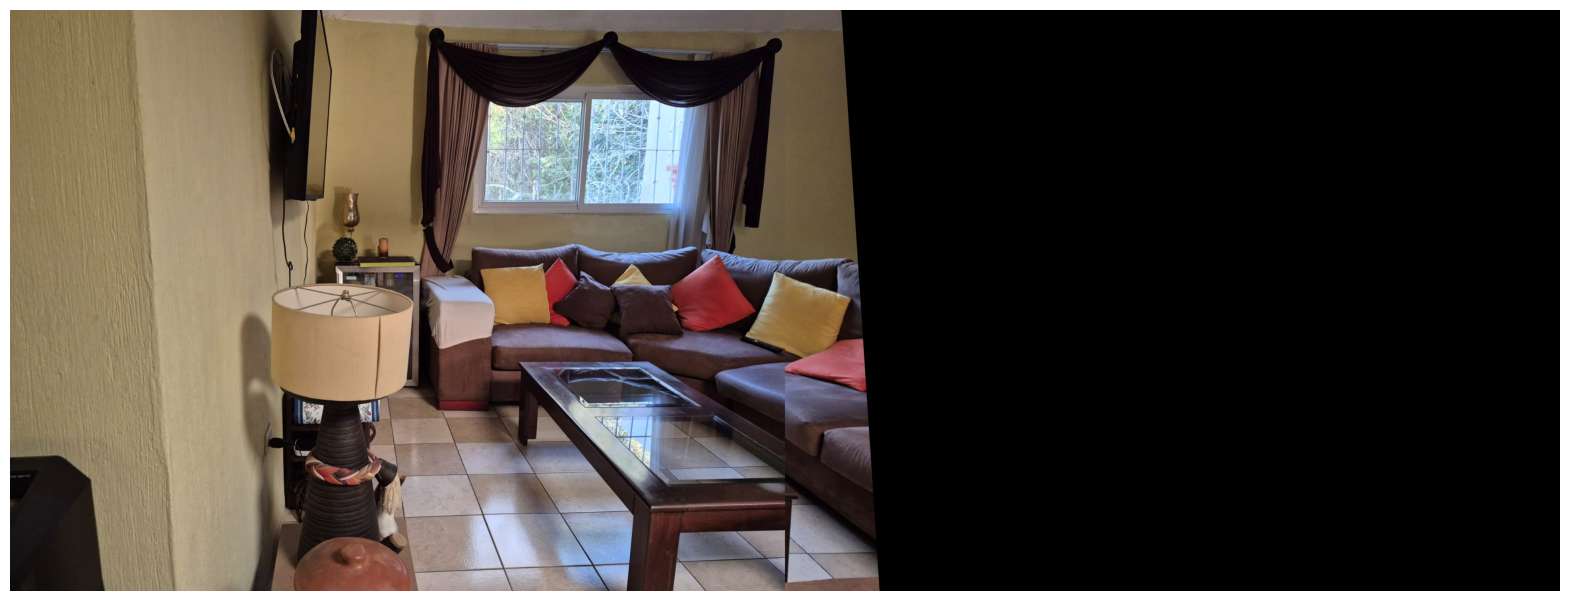

In [15]:
panorama_gray = cv2.cvtColor(panorama, cv2.COLOR_BGR2GRAY)
_, mask = cv2.threshold(panorama_gray, 1, 255, cv2.THRESH_BINARY)
mask_inv = cv2.bitwise_not(mask)
left_on_canvas = np.zeros_like(panorama)
left_on_canvas[0:h_left, 0:w_left] = img_left

img_left_part = cv2.bitwise_and(left_on_canvas, left_on_canvas, mask=mask_inv)
img_panorama_part = cv2.bitwise_and(panorama, panorama, mask=mask)
final_panorama = cv2.add(img_left_part, img_panorama_part)

dst_rgb = cv2.cvtColor(final_panorama, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(20, 10))
plt.imshow(dst_rgb)
plt.axis('off') 
plt.show()

## Task 2

In [ ]:
def ver(img_bgr, titulo=""):
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10,6))
    plt.imshow(img_rgb)
    plt.title(titulo)
    plt.axis("off")
    plt.show()

Izquierda: (1200, 1600, 3)
Derecha: (1200, 1600, 3)


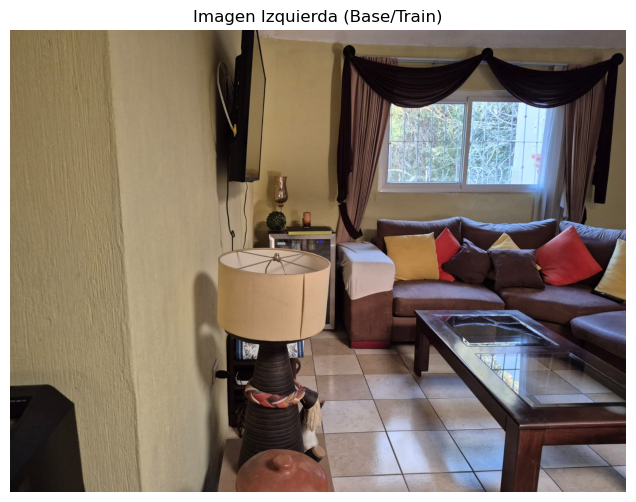

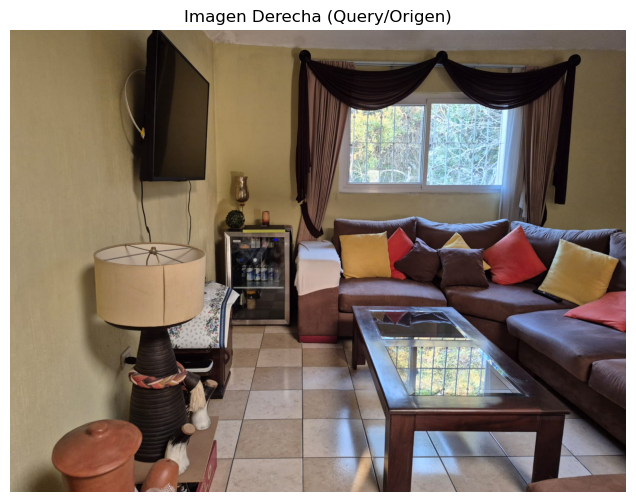

In [2]:
ruta_izq = "des2i.jpeg"  # base/train
ruta_der = "des2d.jpeg"  # query/origen

img_izq = cv2.imread(ruta_izq)
img_der = cv2.imread(ruta_der)

if img_izq is None or img_der is None:
    raise FileNotFoundError("No se pudieron leer las imágenes. Revisa nombres/rutas.")

print("Izquierda:", img_izq.shape)
print("Derecha:", img_der.shape)

ver(img_izq, "Imagen Izquierda (Base/Train)")
ver(img_der, "Imagen Derecha (Query/Origen)")

In [3]:
gris_izq = cv2.cvtColor(img_izq, cv2.COLOR_BGR2GRAY)
gris_der = cv2.cvtColor(img_der, cv2.COLOR_BGR2GRAY)

orb = cv2.ORB_create(3000)

kp_izq, des_izq = orb.detectAndCompute(gris_izq, None)
kp_der, des_der = orb.detectAndCompute(gris_der, None)

bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)
matches = bf.knnMatch(des_der, des_izq, k=2)  # ojo: query=DER, train=IZQ

buenos = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        buenos.append(m)

print("Keypoints izq:", len(kp_izq))
print("Keypoints der:", len(kp_der))
print("Matches (ratio):", len(buenos))

Keypoints izq: 3000
Keypoints der: 3000
Matches (ratio): 176


Inliers (OpenCV RANSAC): 86 de 176


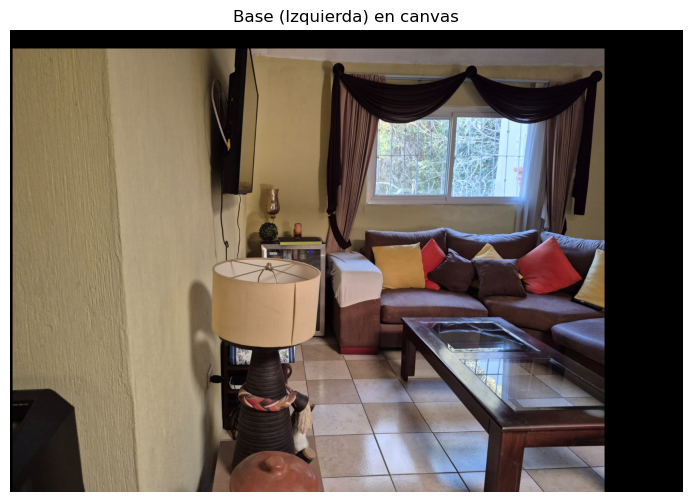

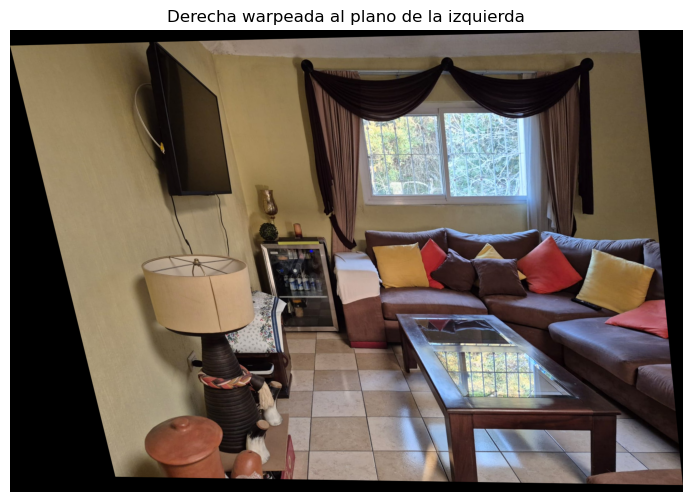

In [4]:
pts_der = np.float32([kp_der[m.queryIdx].pt for m in buenos]).reshape(-1, 1, 2)
pts_izq = np.float32([kp_izq[m.trainIdx].pt for m in buenos]).reshape(-1, 1, 2)

H, mask_in = cv2.findHomography(pts_der, pts_izq, cv2.RANSAC, 5.0)
if H is None:
    raise ValueError("No se pudo estimar homografía.")

print("Inliers (OpenCV RANSAC):", int(mask_in.sum()), "de", len(mask_in))

hL, wL = img_izq.shape[:2]
hR, wR = img_der.shape[:2]

esq_der = np.float32([[0,0],[wR,0],[wR,hR],[0,hR]]).reshape(-1,1,2)
esq_der_w = cv2.perspectiveTransform(esq_der, H)

esq_izq = np.float32([[0,0],[wL,0],[wL,hL],[0,hL]]).reshape(-1,1,2)

todos = np.vstack((esq_izq, esq_der_w))
min_xy = np.floor(todos.min(axis=0).ravel()).astype(int)
max_xy = np.ceil(todos.max(axis=0).ravel()).astype(int)

tx = -min_xy[0] if min_xy[0] < 0 else 0
ty = -min_xy[1] if min_xy[1] < 0 else 0

T = np.array([[1,0,tx],[0,1,ty],[0,0,1]], dtype=np.float64)

W = max_xy[0] - min_xy[0]
Hh = max_xy[1] - min_xy[1]

warp_der = cv2.warpPerspective(img_der, T @ H, (W, Hh))

base_canvas = np.zeros((Hh, W, 3), dtype=np.uint8)
base_canvas[ty:ty+hL, tx:tx+wL] = img_izq

ver(base_canvas, "Base (Izquierda) en canvas")
ver(warp_der, "Derecha warpeada al plano de la izquierda")

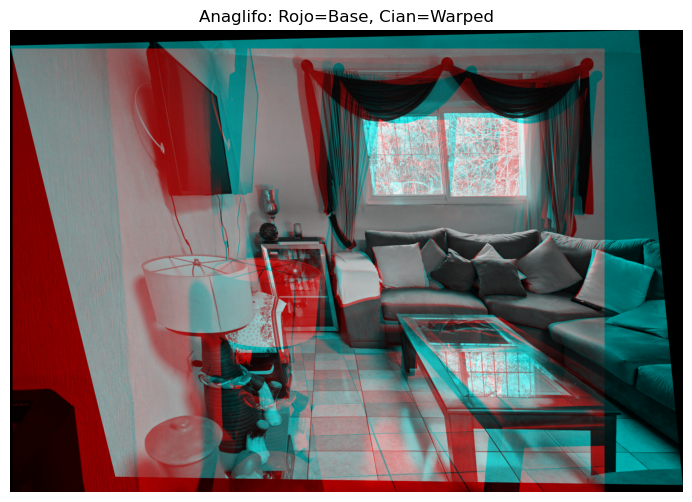

In [5]:
base_g = cv2.cvtColor(base_canvas, cv2.COLOR_BGR2GRAY)
warp_g = cv2.cvtColor(warp_der, cv2.COLOR_BGR2GRAY)

anag = np.zeros_like(base_canvas)
anag[..., 2] = base_g          # Rojo
anag[..., 1] = warp_g          # Verde
anag[..., 0] = warp_g          # Azul  (Verde+Azul = Cian)

ver(anag, "Anaglifo: Rojo=Base, Cian=Warped")

In [9]:
def medir_objeto_opencv(nombre, img_bgr):
    copia = img_bgr.copy()
    puntos = []

    def click(event, x, y, flags, param):
        if event == cv2.EVENT_LBUTTONDOWN:
            puntos.append((x, y))
            cv2.circle(copia, (x, y), 6, (0, 255, 0), -1)
            cv2.imshow(nombre, copia)

    cv2.imshow(nombre, copia)
    cv2.setMouseCallback(nombre, click)

    while True:
        if len(puntos) >= 2:
            break
        if cv2.waitKey(20) & 0xFF == 27:  # ESC para salir
            break

    cv2.destroyWindow(nombre)

    if len(puntos) < 2:
        raise ValueError("No se tomaron 2 puntos.")

    (x1, y1), (x2, y2) = puntos[:2]
    disp = abs(x1 - x2)

    return {
        "objeto": nombre,
        "x1": x1, "y1": y1,
        "x2": x2, "y2": y2,
        "disparidad_px": disp
    }

# uso:
res_A = medir_objeto_opencv("A (Cercano)", anag)
res_B = medir_objeto_opencv("B (Medio)", anag)
res_C = medir_objeto_opencv("C (Fondo)", anag)

for r in [res_A, res_B, res_C]:
    print(r["objeto"], "| disparidad =", r["disparidad_px"], "px")

A (Cercano) | disparidad = 246 px
B (Medio) | disparidad = 85 px
C (Fondo) | disparidad = 20 px


In [11]:
import pandas as pd

tabla = pd.DataFrame([
    {
        "Objeto": "A (Cercano)",
        "x1": res_A["x1"],
        "y1": res_A["y1"],
        "x2": res_A["x2"],
        "y2": res_A["y2"],
        "Disparidad_px": res_A["disparidad_px"],
        "Distancia_real_estimada_m": 0.9
    },
    {
        "Objeto": "B (Medio)",
        "x1": res_B["x1"],
        "y1": res_B["y1"],
        "x2": res_B["x2"],
        "y2": res_B["y2"],
        "Disparidad_px": res_B["disparidad_px"],
        "Distancia_real_estimada_m": 1.8
    },
    {
        "Objeto": "C (Fondo)",
        "x1": res_C["x1"],
        "y1": res_C["y1"],
        "x2": res_C["x2"],
        "y2": res_C["y2"],
        "Disparidad_px": res_C["disparidad_px"],
        "Distancia_real_estimada_m": 4.0
    }
])

tabla

,Objeto,x1,y1,x2,y2,Disparidad_px,Distancia_real_estimada_m
0,A (Cercano),395,53,641,70,246,0.9
1,B (Medio),788,91,873,103,85,1.8
2,C (Fondo),1444,534,1464,533,20,4.0


Se observa que la disparidad disminuye conforme aumenta la distancia del objeto, lo cual es consistente con el principio de estereovisión.

## Task 3

1. Sí existe una tendencia clara y muy marcada: la disparidad disminuye fuertemente a medida que aumenta la distancia real del objeto. El objeto más cercano (0.9 m) tiene una disparidad muy alta (246 px), el objeto a distancia media (1.8 m) baja considerablemente (85 px), y el objeto más lejano (4.0 m) presenta una disparidad muy pequeña (20 px). La relación no es leve ni ambigua: la caída es drástica y consistente, lo que confirma empíricamente que los objetos cercanos sufren mucho más desplazamiento por paralaje que los lejanos.

2. La relación claramente se comporta como una función inversa  d=k/Z, no lineal. Si fuera lineal, al duplicarse la distancia (de 0.9 m a 1.8 m), la disparidad debería duplicarse también, pero ocurre lo contrario: cae de 246 px a 85 px (casi tres veces menor). Luego, al aumentar la distancia a 4.0 m, la disparidad baja aún más hasta 20 px. La forma en que disminuye la disparidad al aumentar Z es consistente con el modelo teórico de estereoscopía, donde la profundidad es inversamente proporcional a la disparidad.

3. El algoritmo de homografía falló en alinear los objetos cercanos porque asume que toda la escena puede modelarse como un solo plano proyectivo. Sin embargo, tus datos muestran que cada profundidad genera una disparidad distinta (246 px vs 20 px es una diferencia enorme). La homografía solo puede alinear correctamente un plano dominante (en tu caso, el fondo), pero no puede compensar los desplazamientos diferenciales causados por la traslación lateral. Ese “error” revela información tridimensional: la variación en disparidad que mediste contiene directamente la información de profundidad de la escena, que es precisamente el principio físico-matemático que utiliza la visión estéreo para reconstrucción 3D.